In [46]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

conexao = ("Server=DESKTOP-OICCGK1;"
           "Driver=SQL Server;"
           "Database=ContosoRetailDW;"
           "Trusted connection=yes")

dados = pyodbc.connect(conexao)

comando_sql = """
SELECT 
	RIGHT(CalendarMonth,2) AS 'Mês',
	CalendarYear AS 'Ano',
	(SUM(SalesAmount) - SUM(DiscountAmount)) AS 'Total Faturado'
FROM FactSales AS f
LEFT JOIN DimDate AS d
	ON f.DateKey = d.Datekey
GROUP BY
	CalendarMonth,
	CalendarYear
ORDER BY 
	CalendarYear,
	CalendarMonth 
"""

In [74]:
tabela = pd.read_sql(comando_sql,dados)
tabela["Total Faturado"] = pd.to_numeric(tabela["Total Faturado"])
#display(tabela)

vendas_2007 = tabela[tabela["Ano"] == 2007]
display(vendas_2007)

vendas_2008 = tabela[tabela["Ano"] == 2008]
display(vendas_2008)

vendas_2009 = tabela[tabela["Ano"] == 2009]
display(vendas_2009)

C:\Users\usu\AppData\Local\Temp\ipykernel_18112\601118533.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tabela = pd.read_sql(comando_sql,dados)


,Mês,Ano,Total Faturado
0,01,2007,2.634282e+08
1,02,2007,2.928843e+08
2,03,2007,2.947441e+08
3,04,2007,3.977448e+08
4,05,2007,4.221731e+08
5,06,2007,4.085913e+08
6,07,2007,3.851680e+08
7,08,2007,3.818186e+08
8,09,2007,3.726426e+08
9,10,2007,4.191391e+08


,Mês,Ano,Total Faturado
12,01,2008,2.734619e+08
13,02,2008,2.835911e+08
14,03,2008,2.847113e+08
15,04,2008,3.525112e+08
16,05,2008,3.496281e+08
17,06,2008,3.367394e+08
18,07,2008,3.821147e+08
19,08,2008,3.546627e+08
20,09,2008,3.482616e+08
21,10,2008,3.234016e+08


,Mês,Ano,Total Faturado
24,01,2009,2.639038e+08
25,02,2009,2.606479e+08
26,03,2009,2.652144e+08
27,04,2009,3.059309e+08
28,05,2009,3.398421e+08
29,06,2009,3.296038e+08
30,07,2009,3.299704e+08
31,08,2009,3.203406e+08
32,09,2009,3.093172e+08
33,10,2009,3.242930e+08


[ 1  2  3  4  5  6  7  8  9 10 11 12]


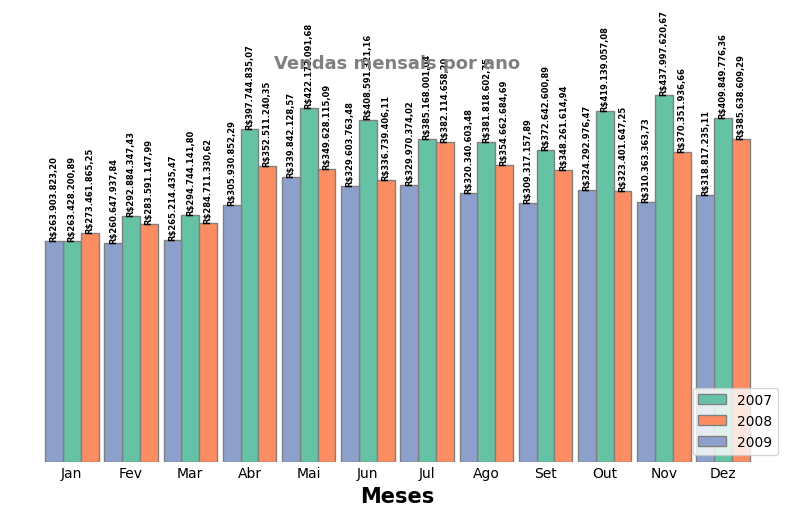

In [123]:
from cycler import cycler

cores = plt.get_cmap("Set2").colors
ciclo = cycler(color = cores)
plt.rc("axes", prop_cycle=ciclo)

def format_money(valor):
    return "R${:,.2f}".format(valor).replace(",","x").replace(".",",").replace("x",".")

meses = np.arange(len(vendas_2007["Mês"])) + 1
print(meses)
largura = 0.3
p2007 = meses 
p2008 = meses + largura
p2009 = meses - largura

plt.figure(figsize=(10,5))
plt.title("Vendas mensais por ano",fontweight="bold",fontsize=13,color="gray")
plt.xlabel("Meses",fontsize=15,fontweight="bold")

barras2007 = plt.bar(p2007,vendas_2007["Total Faturado"],label="2007",width=largura,edgecolor="gray")
plt.bar_label(barras2007,vendas_2007["Total Faturado"].apply(format_money),fontsize=6,rotation=90,fontweight="bold")

barras2008 = plt.bar(p2008,vendas_2008["Total Faturado"],label="2008",width=largura,edgecolor="gray")
plt.bar_label(barras2008,vendas_2008["Total Faturado"].apply(format_money),fontsize=6,rotation=90,fontweight="bold")

barras2009 = plt.bar(p2009,vendas_2009["Total Faturado"],label="2009",width=largura,edgecolor="gray")
plt.bar_label(barras2009,vendas_2009["Total Faturado"].apply(format_money),fontsize=6,rotation=90,fontweight="bold")

plt.yticks([])
plt.xticks(meses,["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
plt.tick_params("x",length=0)
plt.legend(loc="lower right")

plt.box(False)

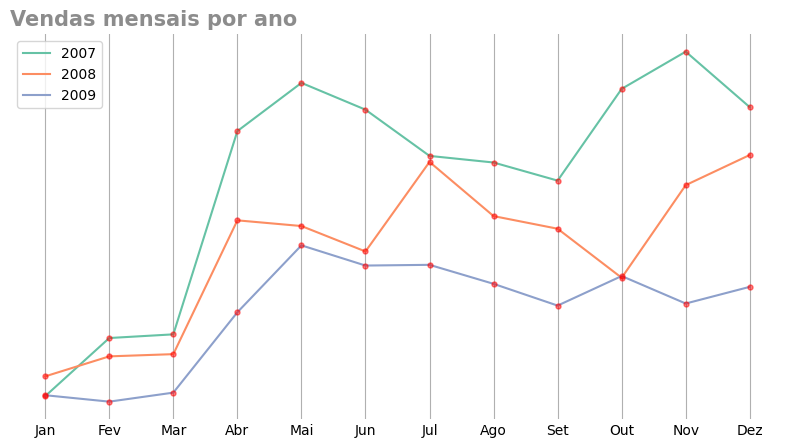

In [110]:
plt.figure(figsize=(10,5))
plt.title("Vendas mensais por ano",fontsize=15,color="gray",alpha=0.9,loc="left",fontweight="bold")
plt.box(False)
plt.grid(True)


plt.plot(meses,vendas_2007["Total Faturado"],label="2007")
plt.scatter(meses,vendas_2007["Total Faturado"],zorder=5,s=13,color="red",alpha=0.5)

plt.plot(meses,vendas_2008["Total Faturado"],label="2008")
plt.scatter(meses,vendas_2008["Total Faturado"],zorder=5,s=13,color="red",alpha=0.5)

plt.plot(meses,vendas_2009["Total Faturado"],label="2009")
plt.scatter(meses,vendas_2009["Total Faturado"],zorder=5,s=13,color="red",alpha=0.5)

plt.tick_params("x",length=0)
plt.xticks(meses,["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
plt.yticks([])

plt.legend()

